<a href="https://colab.research.google.com/github/Brawnet/Data-Mining-Yehezkiel-Chandra/blob/main/Group_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Data Preprocessing**

AHNAF RAFLI, 0706022310045
MUH NUR ALIF AKBAR, 0706022310031
YEHEZKIEL CHANDRA PUTRA CAHYONO, 0706022310038

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from matplotlib import pyplot as plt
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering, KMeans
from scipy.cluster import hierarchy
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.metrics import silhouette_score

In [ ]:
url = "https://raw.githubusercontent.com/aliplip01/ALP_Bintel/main/marketing_campaign.csv"
df = pd.read_csv(url, sep='\t')

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [ ]:
df.describe(include='all')

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2240,2240,2216.000000,2240.000000,2240.000000,2240,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
unique,NaN,NaN,5,8,NaN,NaN,NaN,663,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Graduation,Married,NaN,NaN,NaN,31-08-2012,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,1127,864,NaN,NaN,NaN,12,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,5592.159821,1968.805804,NaN,NaN,52247.251354,0.444196,0.506250,NaN,49.109375,303.935714,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,NaN,NaN,25173.076661,0.538398,0.544538,NaN,28.962453,336.597393,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,NaN,NaN,1730.000000,0.000000,0.000000,NaN,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,NaN,NaN,35303.000000,0.000000,0.000000,NaN,24.000000,23.750000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,NaN,NaN,51381.500000,0.000000,0.000000,NaN,49.000000,173.500000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,NaN,NaN,68522.000000,1.000000,1.000000,NaN,74.000000,504.250000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000


In [ ]:
for col in df.columns:
    print(f"\n{col} unique values:")
    print(df[col].unique())


ID unique values:
[5524 2174 4141 ... 7270 8235 9405]

Year_Birth unique values:
[1957 1954 1965 1984 1981 1967 1971 1985 1974 1950 1983 1976 1959 1952
 1987 1946 1980 1949 1982 1979 1951 1969 1986 1989 1963 1970 1973 1943
 1975 1996 1968 1964 1977 1978 1955 1966 1988 1948 1958 1972 1960 1945
 1991 1962 1953 1961 1956 1992 1900 1893 1990 1947 1899 1993 1994 1941
 1944 1995 1940]

Education unique values:
['Graduation' 'PhD' 'Master' 'Basic' '2n Cycle']

Marital_Status unique values:
['Single' 'Together' 'Married' 'Divorced' 'Widow' 'Alone' 'Absurd' 'YOLO']

Income unique values:
[58138. 46344. 71613. ... 56981. 69245. 52869.]

Kidhome unique values:
[0 1 2]

Teenhome unique values:
[0 1 2]

Dt_Customer unique values:
['04-09-2012' '08-03-2014' '21-08-2013' '10-02-2014' '19-01-2014'
 '09-09-2013' '13-11-2012' '08-05-2013' '06-06-2013' '13-03-2014'
 '15-11-2013' '10-10-2012' '24-11-2012' '24-12-2012' '31-08-2012'
 '28-03-2013' '03-11-2012' '08-08-2012' '06-01-2013' '23-12-2012'
 '11-01-

In [ ]:
df.isna().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [ ]:
df = df.dropna()

In [ ]:
numeric_cols = [
    'Income', 'MntWines', 'MntFruits', 'MntMeatProducts',
    'MntFishProducts', 'MntSweetProducts', 'MntGoldProds'
]

Q1 = df['Income'].quantile(0.25)
Q3 = df['Income'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['Income'] >= lower) & (df['Income'] <= upper)]

In [ ]:
# Harusnya 0
((df['Income'] < lower) | (df['Income'] > upper)).sum()


np.int64(0)

In [ ]:
df['Income'].describe()

,Income
count,2208.000000
mean,51633.638134
std,20713.376530
min,1730.000000
25%,35196.000000
50%,51301.000000
75%,68289.750000
max,113734.000000


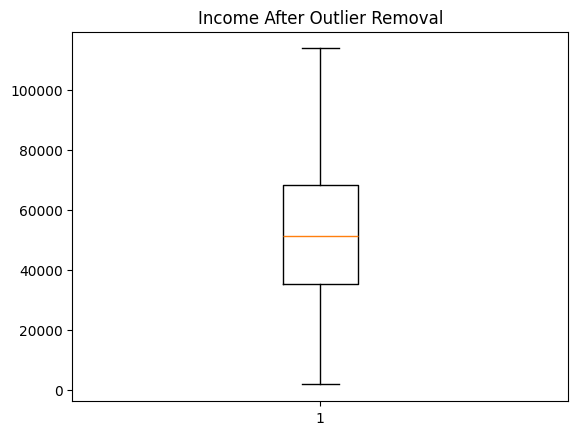

In [ ]:
plt.boxplot(df['Income'])
plt.title("Income After Outlier Removal")
plt.show()

# **Exploratory Data Analysis**

# Profile Customer

In [ ]:
df['Age'] = 2025 - df['Year_Birth']

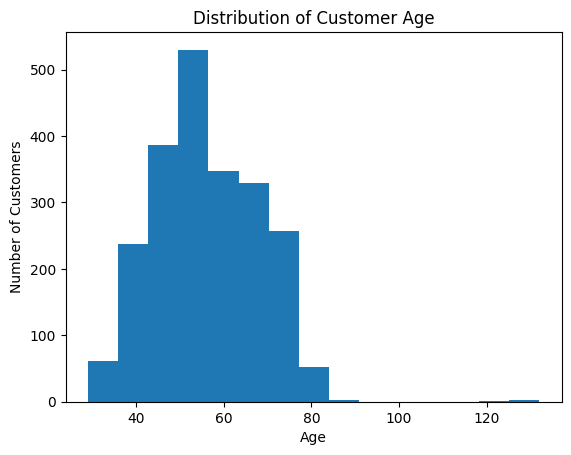

In [ ]:
plt.figure()
plt.hist(df['Age'], bins=15)
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.title('Distribution of Customer Age')
plt.show()

# Total Spending per Kategori Produk

In [ ]:
product_cols = [
    'MntWines',
    'MntFruits',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds'
]

total_spending = df[product_cols].sum()

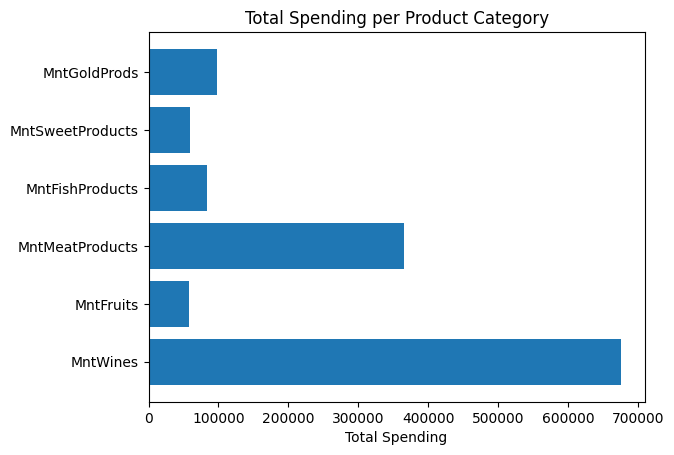

In [ ]:
plt.figure()
plt.barh(total_spending.index, total_spending.values)
plt.xlabel('Total Spending')
plt.title('Total Spending per Product Category')
plt.show()

# Perbandingan Channel Pembelian

In [ ]:
channel_cols = [
    'NumWebPurchases',
    'NumCatalogPurchases',
    'NumStorePurchases'
]

total_channel = df[channel_cols].sum()

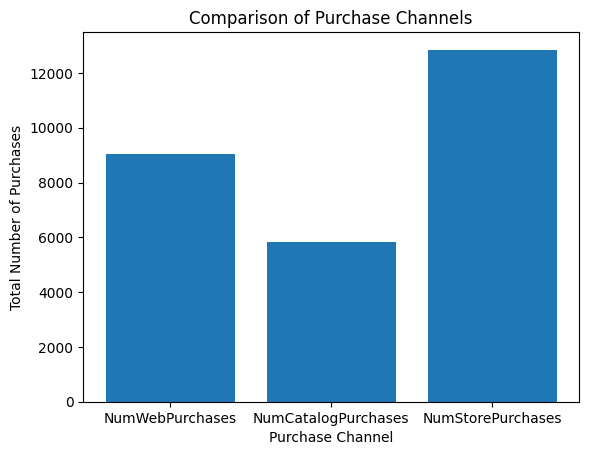

In [ ]:
plt.figure()
plt.bar(total_channel.index, total_channel.values)
plt.xlabel('Purchase Channel')
plt.ylabel('Total Number of Purchases')
plt.title('Comparison of Purchase Channels')
plt.show()

# Data Transformation

In [ ]:
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,0,0,0,0,0,0,3,11,1,68
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,0,0,0,0,0,0,3,11,0,71
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,0,0,0,0,0,0,3,11,0,60
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,0,0,0,0,0,0,3,11,0,41
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,0,0,0,0,0,0,3,11,0,44
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,0,0,0,0,0,0,3,11,0,58
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,0,0,0,1,0,0,3,11,0,79
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,0,1,0,0,0,0,3,11,0,44
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,0,0,0,0,0,0,3,11,0,69


In [ ]:
df_encoded = df.copy()

In [ ]:
categorical_cols = df_encoded.select_dtypes(include='object').columns
categorical_cols

Index(['Education', 'Marital_Status', 'Dt_Customer'], dtype='object')

In [ ]:
df_encoded = df_encoded.drop(columns=['Dt_Customer', 'ID'])

In [ ]:
df_encoded = pd.get_dummies(
    df_encoded,
    columns=['Education', 'Marital_Status'],
    drop_first=False
)

In [ ]:
df_encoded

,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,Education_Master,Education_PhD,Marital_Status_Absurd,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO
0,1957,58138.0,0,0,58,635,88,546,172,88,...,False,False,False,False,False,False,True,False,False,False
1,1954,46344.0,1,1,38,11,1,6,2,1,...,False,False,False,False,False,False,True,False,False,False
2,1965,71613.0,0,0,26,426,49,127,111,21,...,False,False,False,False,False,False,False,True,False,False
3,1984,26646.0,1,0,26,11,4,20,10,3,...,False,False,False,False,False,False,False,True,False,False
4,1981,58293.0,1,0,94,173,43,118,46,27,...,False,True,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,1967,61223.0,0,1,46,709,43,182,42,118,...,False,False,False,False,False,True,False,False,False,False
2236,1946,64014.0,2,1,56,406,0,30,0,0,...,False,True,False,False,False,False,False,True,False,False
2237,1981,56981.0,0,0,91,908,48,217,32,12,...,False,False,False,False,True,False,False,False,False,False
2238,1956,69245.0,0,1,8,428,30,214,80,30,...,True,False,False,False,False,False,False,True,False,False


## **AGGOMERATIVE CLUSTERING**

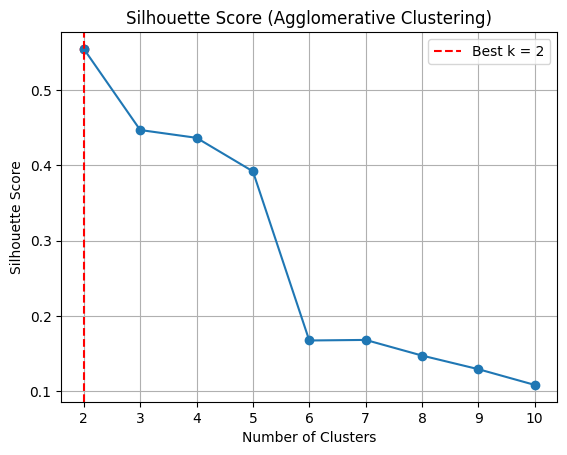

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    model = AgglomerativeClustering(
        n_clusters=k,
        linkage='single'
    )
    labels = model.fit_predict(df_encoded)
    score = silhouette_score(df_encoded, labels)
    silhouette_scores.append(score)

# Cari nilai terbaik
best_k = k_range[np.argmax(silhouette_scores)]
best_score = max(silhouette_scores)

# Plot
plt.figure()
plt.plot(k_range, silhouette_scores, marker='o')
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Best k = {best_k}')
plt.scatter(best_k, best_score, color='red')
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score (Agglomerative Clustering)")
plt.legend()
plt.grid(True)
plt.show()


# Hierarchical Clustering Modeling

Skipping Ward linkage with Manhattan metric (not supported).


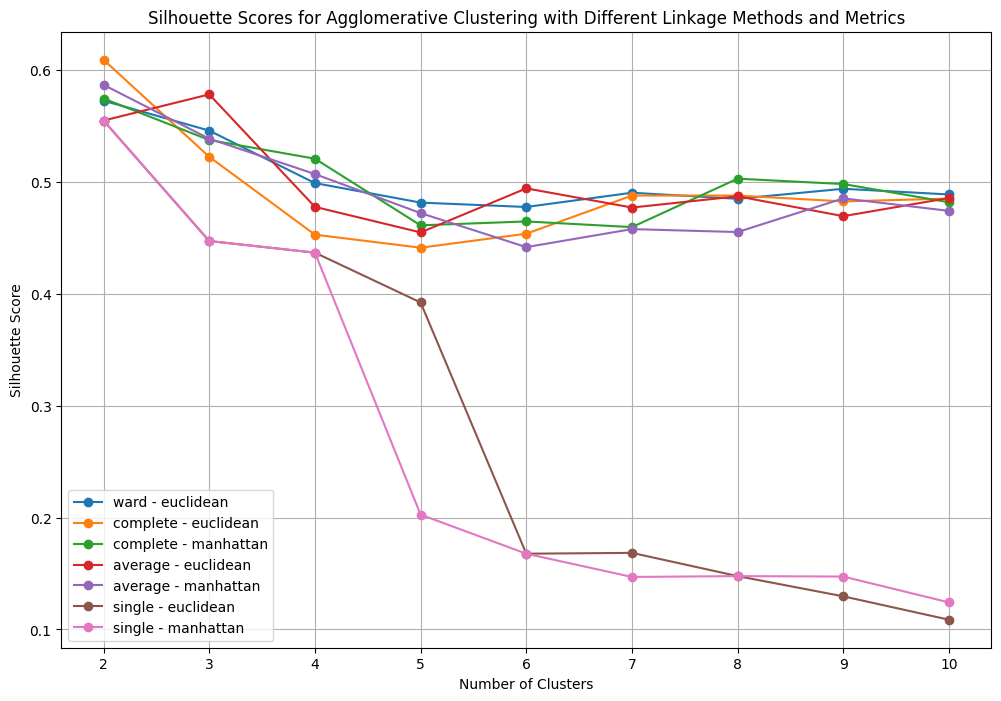

Best Silhouette Score: 0.6088912324207325
Optimal Number of Clusters: 2
Optimal Linkage Method: complete
Optimal Metric: euclidean


In [ ]:
# Define the range of clusters to test and linkage methods
range_n_clusters = range(2, 11)
linkage_methods = ['ward', 'complete', 'average', 'single']
metrics = ['euclidean', 'manhattan']

best_silhouette_score = -1
best_n_clusters = 0
best_linkage = ''
best_metric = ''

results_for_plotting = []

for linkage_method in linkage_methods:
    for metric in metrics:
        # Skip 'ward' linkage with 'manhattan' metric as it's not supported
        if linkage_method == 'ward' and metric == 'manhattan':
            print(f"Skipping Ward linkage with Manhattan metric (not supported).")
            continue

        current_scores = []
        for n_clusters in range_n_clusters:
            agglo = AgglomerativeClustering(n_clusters=n_clusters, linkage=linkage_method, metric=metric)
            y_agglo = agglo.fit_predict(df_encoded)
            silhouette_avg = silhouette_score(df_encoded, y_agglo)
            current_scores.append(silhouette_avg)

            if silhouette_avg > best_silhouette_score:
                best_silhouette_score = silhouette_avg
                best_n_clusters = n_clusters
                best_linkage = linkage_method
                best_metric = metric
        results_for_plotting.append({
            'linkage': linkage_method,
            'metric': metric,
            'scores': current_scores
        })

# Plot the silhouette scores for each linkage method and metric combination
plt.figure(figsize=(12, 8))
for result in results_for_plotting:
    plt.plot(range_n_clusters, result['scores'], marker='o', label=f"{result['linkage']} - {result['metric']}")

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores for Agglomerative Clustering with Different Linkage Methods and Metrics")
plt.legend()
plt.grid(True)
plt.show()

print(f"Best Silhouette Score: {best_silhouette_score}")
print(f"Optimal Number of Clusters: {best_n_clusters}")
print(f"Optimal Linkage Method: {best_linkage}")
print(f"Optimal Metric: {best_metric}")

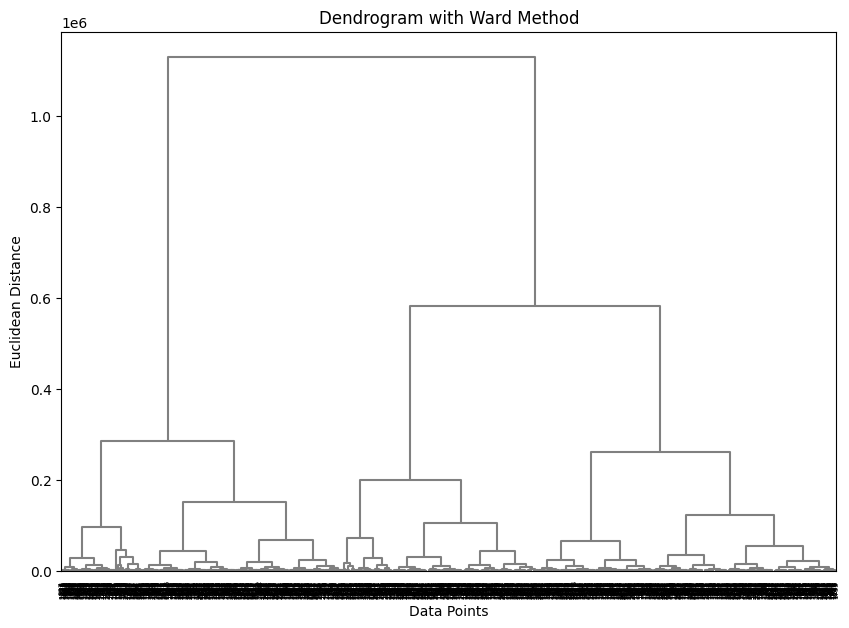

In [ ]:
# Ward Method
linked = linkage(df_encoded, method='ward', metric='euclidean')

# Plot dendrogram dengan color_threshold
plt.figure(figsize=(10, 7))
sch.dendrogram(linked, above_threshold_color="grey", color_threshold=7.5)
plt.title("Dendrogram with Ward Method")
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance")
plt.show()

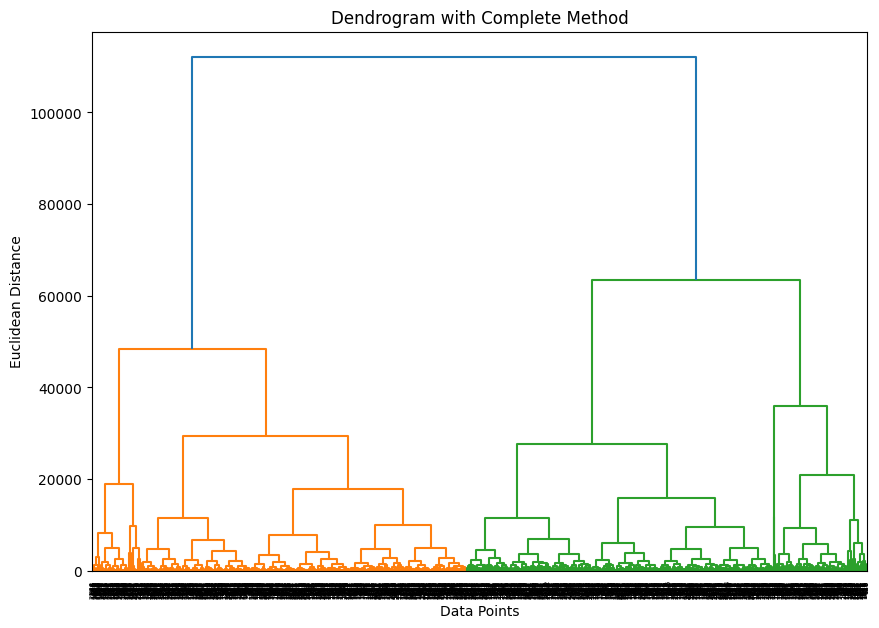

In [ ]:
# Max Distance
linked = linkage(df_encoded, method='complete', metric='euclidean')

# Plot dendrogram dengan color_threshold
plt.figure(figsize=(10, 7))
sch.dendrogram(linked)
plt.title("Dendrogram with Complete Method")
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance")
plt.show()

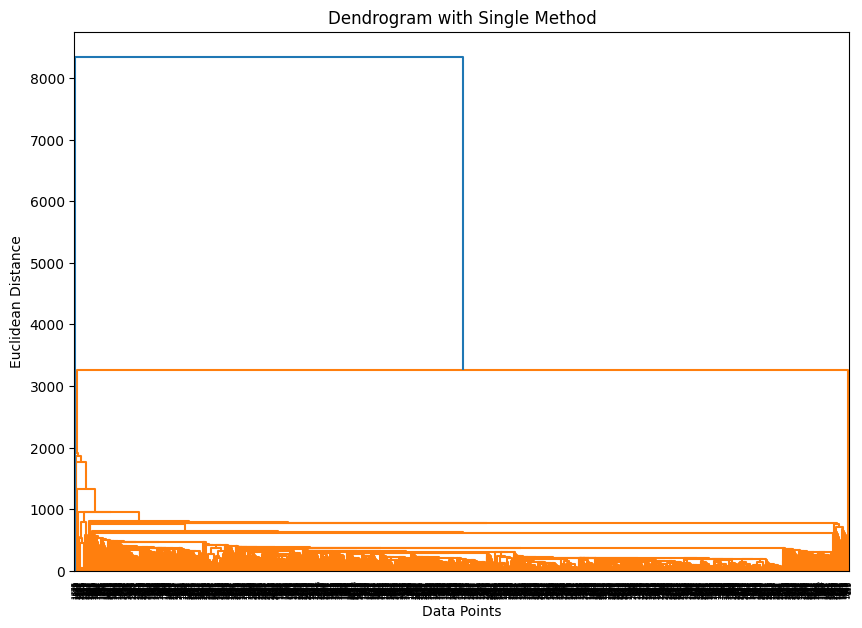

In [ ]:
# Min Distance
linked = linkage(df_encoded, method='single')

# Plot dendrogram dengan color_threshold yang sesuai
plt.figure(figsize=(10, 7))
sch.dendrogram(linked)
plt.title("Dendrogram with Single Method")
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance")
plt.show()

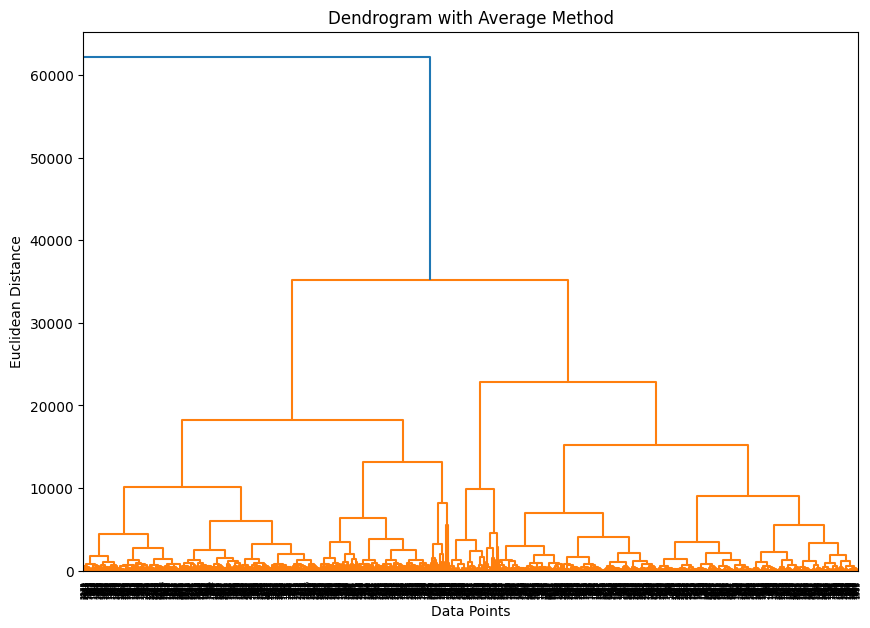

In [ ]:
# Average Distance
linked = linkage(df_encoded, method='average', metric='euclidean')

# Plot dendrogram dengan color_threshold
plt.figure(figsize=(10, 7))
sch.dendrogram(linked)
plt.title("Dendrogram with Average Method")
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance")
plt.show()

## Hierarchical Clustering Model

In [ ]:
# Hierarchical Clustering
agglo = AgglomerativeClustering(n_clusters=best_n_clusters, linkage=best_linkage, metric=best_metric)
y_hc = agglo.fit_predict(df_encoded)

In [ ]:
# Evaluation
ss = silhouette_score(df_encoded, y_hc)
print(ss)

0.6088912324207325


## Dendogram Visualization for Hierarchical Clustering Model

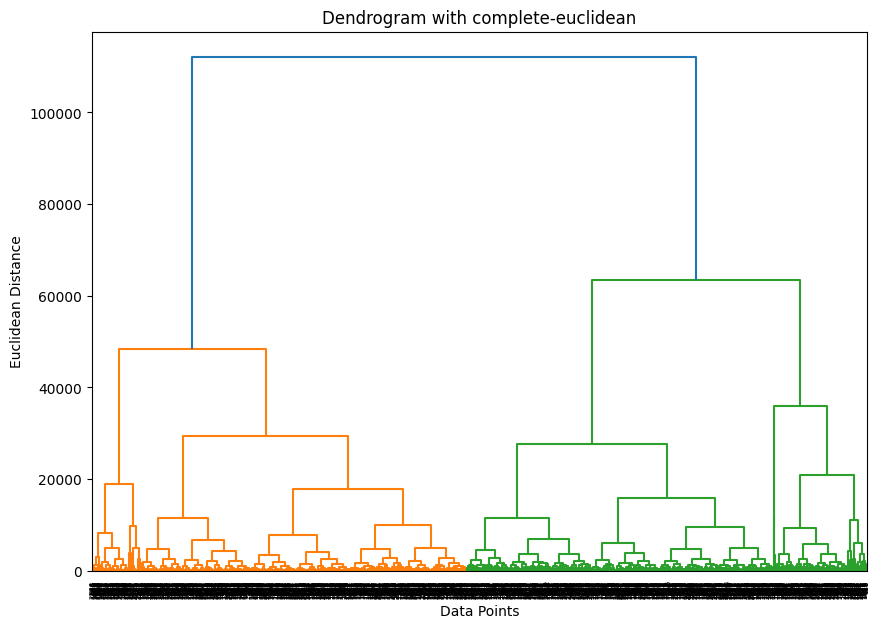

In [ ]:
# Average Distance
linked = linkage(df_encoded, method=best_linkage, metric=best_metric)

# Plot dendrogram dengan color_threshold
plt.figure(figsize=(10, 7))
sch.dendrogram(linked)
plt.title("Dendrogram with " + best_linkage + "-" + best_metric)
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance")
plt.show()

## Merge with the original data

In [ ]:
# Add the cluster labels to the original data
df['Agglo'] = y_hc

# Analyze the clusters with the original values
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Agglo
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,0,0,0,0,0,3,11,1,68,0
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,0,0,0,0,0,3,11,0,71,1
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,0,0,0,0,0,3,11,0,60,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,0,0,0,0,0,3,11,0,41,1
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,0,0,0,0,0,3,11,0,44,0


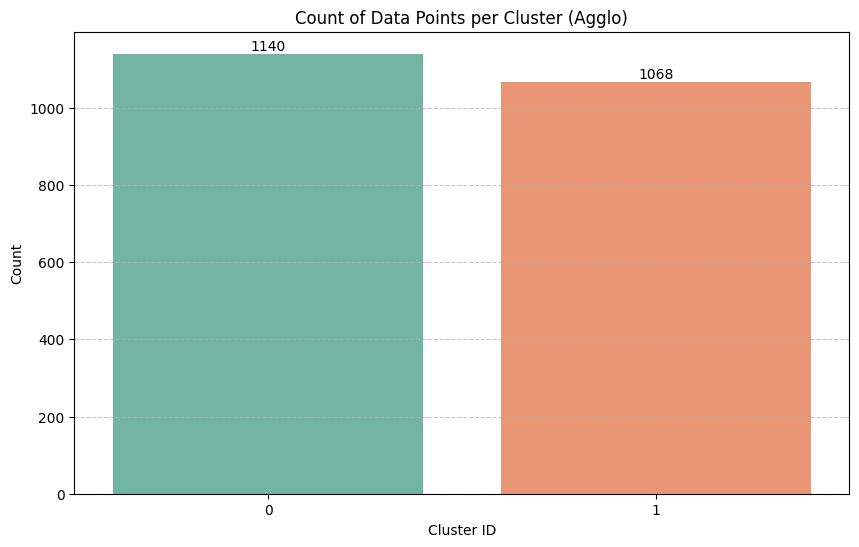

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Get the counts of each cluster in the 'Agglo' column of df
cluster_counts = df['Agglo'].value_counts().sort_index()

# Create a bar plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=cluster_counts.index, y=cluster_counts.values, hue=cluster_counts.index, palette='Set2', legend=False)

# Add labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge')

plt.title('Count of Data Points per Cluster (Agglo)')
plt.xlabel('Cluster ID')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
df['TotalSpending'] = (
    df['MntWines'] +
    df['MntFruits'] +
    df['MntMeatProducts'] +
    df['MntFishProducts'] +
    df['MntSweetProducts'] +
    df['MntGoldProds']
)

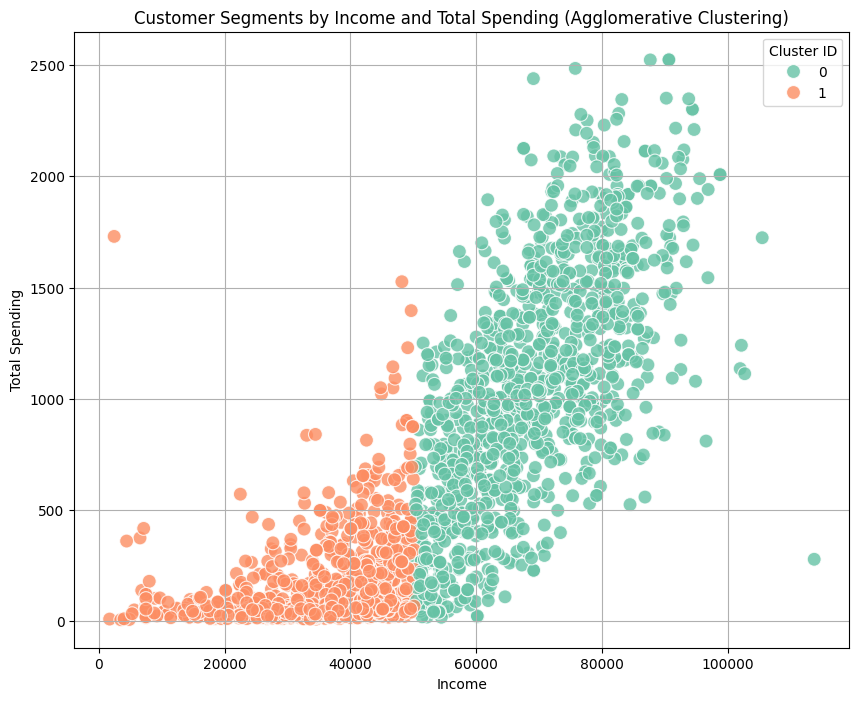

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=df,
    x='Income',
    y='TotalSpending',
    hue='Agglo',
    palette='Set2',
    s=100,
    alpha=0.8
)

plt.title('Customer Segments by Income and Total Spending (Agglomerative Clustering)')
plt.xlabel('Income')
plt.ylabel('Total Spending')
plt.legend(title='Cluster ID')
plt.grid(True)
plt.show()


In [ ]:
import plotly.express as px

fig = px.scatter_3d(
    df,
    x='Age',
    y='Income',
    z='TotalSpending',
    color=df['Agglo'].astype(str),
    title='Interactive 3D Scatter Plot of Customers by Agglomerative Clusters',
    labels={
        'Age': 'Age (Years)',
        'Income': 'Income',
        'TotalSpending': 'Total Spending'
    }
)

fig.show()


In [ ]:
cluster_summary = df.groupby('Agglo').agg({
    'Age': ['mean', 'std', 'min', 'max'],
    'Income': ['mean', 'std', 'min', 'max'],
    'TotalSpending': ['mean', 'std', 'min', 'max'],
    'Agglo': 'count'
})

# Rename columns biar rapi
cluster_summary.columns = [
    'Age_mean', 'Age_std', 'Age_min', 'Age_max',
    'Income_mean', 'Income_std', 'Income_min', 'Income_max',
    'Spending_mean', 'Spending_std', 'Spending_min', 'Spending_max',
    'Customer_Count'
]

cluster_summary

,Age_mean,Age_std,Age_min,Age_max,Income_mean,Income_std,Income_min,Income_max,Spending_mean,Spending_std,Spending_min,Spending_max,Customer_Count
Agglo,,,,,,,,,,,,,
0,58.607018,12.170862,30,132,68623.943860,11364.241629,50272.0,113734.0,1035.250877,536.925667,16,2525,1140
1,53.616105,11.245101,29,125,33497.918539,10580.550991,1730.0,50200.0,149.621723,191.695921,5,1730,1068


## **KMEANS**

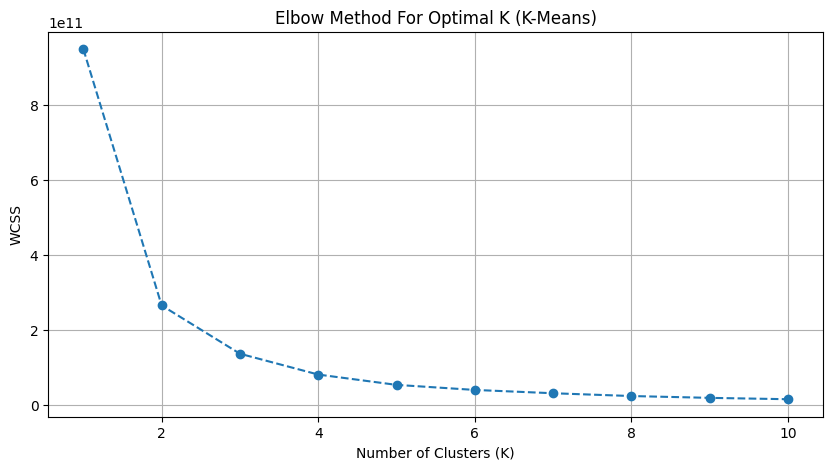

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(df_encoded)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal K (K-Means)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()




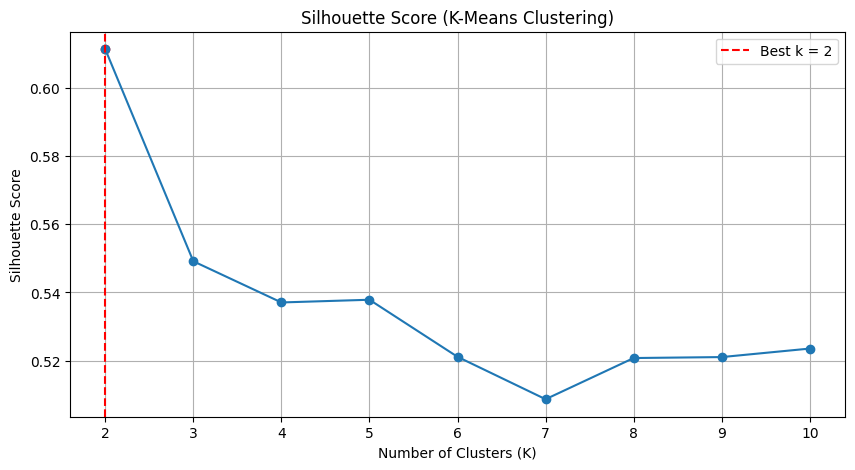

Optimal K for K-Means (based on Silhouette Score): 2
Best Silhouette Score for K-Means: 0.6112227439995098


In [ ]:
# Silhouette Score to find optimal k
silhouette_scores_kmeans = []
k_range_kmeans = range(2, 11) # Silhouette score requires at least 2 clusters

for k in k_range_kmeans:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_encoded)
    score = silhouette_score(df_encoded, labels)
    silhouette_scores_kmeans.append(score)

# Find the best k
best_k_kmeans = k_range_kmeans[np.argmax(silhouette_scores_kmeans)]
best_score_kmeans = max(silhouette_scores_kmeans)

plt.figure(figsize=(10, 5))
plt.plot(k_range_kmeans, silhouette_scores_kmeans, marker='o')
plt.axvline(x=best_k_kmeans, color='red', linestyle='--', label=f'Best k = {best_k_kmeans}')
plt.scatter(best_k_kmeans, best_score_kmeans, color='red')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score (K-Means Clustering)")
plt.legend()
plt.grid(True)
plt.show()

print(f"Optimal K for K-Means (based on Silhouette Score): {best_k_kmeans}")
print(f"Best Silhouette Score for K-Means: {best_score_kmeans}")

In [ ]:
# Apply K-Means with the optimal number of clusters
optimal_k_kmeans = best_k_kmeans # Use the optimal k found from silhouette score
kmeans_model = KMeans(n_clusters=optimal_k_kmeans, init='k-means++', random_state=42, n_init=10)
y_kmeans = kmeans_model.fit_predict(df_encoded)

# Add K-Means cluster labels to the original DataFrame
df['KMeans'] = y_kmeans
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Agglo,TotalSpending,KMeans
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,0,0,0,3,11,1,68,0,1617,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,0,0,0,3,11,0,71,1,27,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,0,0,0,3,11,0,60,0,776,1
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,0,0,0,3,11,0,41,1,53,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,0,0,0,3,11,0,44,0,422,1


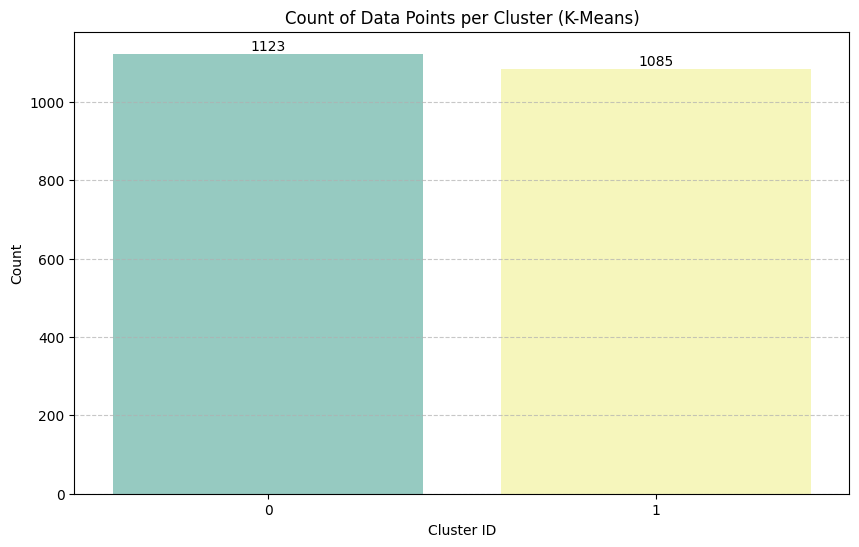

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Get the counts of each cluster in the 'KMeans' column of df
cluster_counts_kmeans = df['KMeans'].value_counts().sort_index()

# Create a bar plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=cluster_counts_kmeans.index, y=cluster_counts_kmeans.values, hue=cluster_counts_kmeans.index, palette='Set3', legend=False)

# Add labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge')

plt.title('Count of Data Points per Cluster (K-Means)')
plt.xlabel('Cluster ID')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

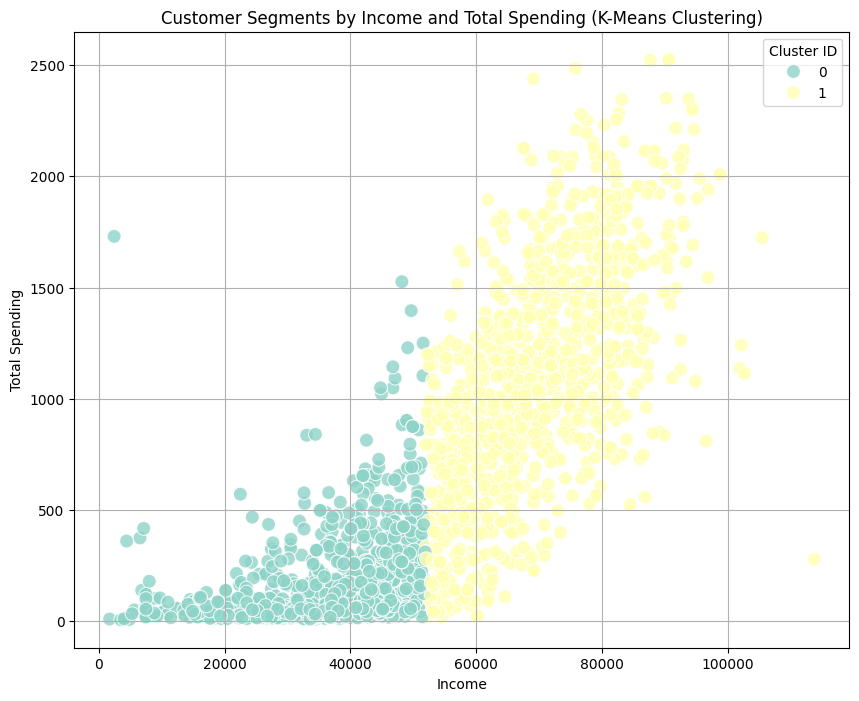

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=df,
    x='Income',
    y='TotalSpending',
    hue='KMeans',
    palette='Set3',
    s=100,
    alpha=0.8
)

plt.title('Customer Segments by Income and Total Spending (K-Means Clustering)')
plt.xlabel('Income')
plt.ylabel('Total Spending')
plt.legend(title='Cluster ID')
plt.grid(True)
plt.show()

In [ ]:
import plotly.express as px

fig = px.scatter_3d(
    df,
    x='Age',
    y='Income',
    z='TotalSpending',
    color=df['KMeans'].astype(str),
    title='Interactive 3D Scatter Plot of Customers by K-Means Clusters',
    labels={
        'Age': 'Age (Years)',
        'Income': 'Income',
        'TotalSpending': 'Total Spending'
    }
)

fig.show()

In [ ]:
cluster_summary = df.groupby('Agglo').agg({
    'Age': ['mean', 'std', 'min', 'max'],
    'Income': ['mean', 'std', 'min', 'max'],
    'TotalSpending': ['mean', 'std', 'min', 'max'],
    'Agglo': 'count'
})

# Rename columns for clarity
cluster_summary.columns = [
    'Age_mean', 'Age_std', 'Age_min', 'Age_max',
    'Income_mean', 'Income_std', 'Income_min', 'Income_max',
    'Spending_mean', 'Spending_std', 'Spending_min', 'Spending_max',
    'Customer_Count'
]

kmeans_cluster_summary = df.groupby('KMeans').agg({
    'Age': ['mean', 'std', 'min', 'max'],
    'Income': ['mean', 'std', 'min', 'max'],
    'TotalSpending': ['mean', 'std', 'min', 'max'],
    'KMeans': 'count'
})

# Rename columns for clarity
kmeans_cluster_summary.columns = [
    'Age_mean', 'Age_std', 'Age_min', 'Age_max',
    'Income_mean', 'Income_std', 'Income_min', 'Income_max',
    'Spending_mean', 'Spending_std', 'Spending_min', 'Spending_max',
    'Customer_Count'
]

print("K-Means Cluster Summary:")
print(kmeans_cluster_summary)

print("\nAgglomerative Cluster Summary (for comparison):")
print(cluster_summary)

K-Means Cluster Summary:
         Age_mean    Age_std  Age_min  Age_max   Income_mean    Income_std  \
KMeans                                                                       
0       54.040071  11.421951       29      125  34356.941229  10991.465737   
1       58.421198  12.164710       30      132  69515.417512  10917.897548   

        Income_min  Income_max  Spending_mean  Spending_std  Spending_min  \
KMeans                                                                      
0           1730.0     51876.0     159.876224    200.822018             5   
1          51948.0    113734.0    1069.530876    524.480777            16   

        Spending_max  Customer_Count  
KMeans                                
0               1730            1123  
1               2525            1085  

Agglomerative Cluster Summary (for comparison):
        Age_mean    Age_std  Age_min  Age_max   Income_mean    Income_std  \
Agglo                                                                  

Dari Hasil yang kita dapatkan hasilnya cukup sama, hanya saja di jika di Agglo 0 untuk pembeli yang memiliki income besar dan spending tinggi, sementara di k-means itu sebaliknya simpelnya untuk K_means 0 adalah Agglo 1, dan K_Means 1 adalah Agglo 0. untuk analisis Business kita akan menggunakan AGGLO



CLUSTER 0 Agglo/1 KMeans — High-Value Mature Customers

(1140 pelanggan)

Karakteristik:

Usia rata-rata: 58.6 tahun
Income rata-rata: ~68.6k (tinggi & stabil)
Total spending rata-rata: ~1,035 (SANGAT tinggi)
Rentang spending luas → pelanggan aktif & loyal
Interpretasi:

Cluster ini adalah: pelanggan mapan, berdaya beli tinggi, dan terbiasa berbelanja lintas kategori produk. Mereka tidak impulsif, tapi konsisten.

CLUSTER 1 Agglo/0 KMeans — Low-Income Price-Sensitive Customers

(1068 pelanggan)

Karakteristik:

Usia rata-rata: 53.6 tahun
Income rata-rata: ~33.5k (jauh lebih rendah)
Total spending rata-rata: ~150 (rendah)
Variansi spending kecil → pembelian terbatas
Interpretasi:

Cluster ini: membeli karena kebutuhan atau promo, bukan loyalitas. Mereka tidak “jelek”, tapi berbeda tujuan.

# **Strategi Bisnis**

**`Strategi 1 – Reverse Loyalty Program`**

Alih-alih memberikan diskon kepada pelanggan bernilai tinggi, perusahaan dapat membangun loyalitas emosional dengan memberi status dan keterlibatan langsung kepada pelanggan pada cluster berpendapatan dan pengeluaran tinggi. Pelanggan ini dapat dilibatkan dalam program eksklusif seperti akses awal terhadap produk baru, undangan preview, atau kesempatan memberikan masukan dan voting terhadap pengembangan produk, sehingga mereka merasa dihargai dan menjadi bagian penting dari ekosistem bisnis tanpa harus mengorbankan margin keuntungan.

**`Strategi 2 – Silent Upselling melalui Bundling Rekomendasi`**

Untuk pelanggan dengan daya beli tinggi, strategi peningkatan pendapatan dapat dilakukan melalui bundling produk yang ditawarkan sebagai rekomendasi personal tanpa label promosi atau diskon. Pendekatan ini memanfaatkan kecenderungan pelanggan yang tidak sensitif terhadap harga namun menghargai kenyamanan dan relevansi, sehingga nilai transaksi rata-rata dapat meningkat secara alami tanpa merusak persepsi premium terhadap merek.

**`Strategi 3 – Diferensiasi Peran Segmen Tanpa Konversi Paksa`**

Pelanggan dengan pendapatan dan pengeluaran rendah tidak perlu dipaksa untuk meningkatkan nilai belanjanya, melainkan diarahkan sebagai segmen penopang volume penjualan yang stabil. Dengan menyediakan produk yang sesuai kebutuhan dasar dan promosi yang terkontrol, segmen ini dapat menjaga arus transaksi rutin dengan biaya pemasaran yang rendah, sekaligus menghindari risiko erosi margin dan citra merek akibat strategi diskon berlebihan.

**`Strategi 4 – Optimalisasi Waktu Komunikasi Berdasarkan Usia`**

Perbedaan karakteristik usia antar cluster dapat dimanfaatkan melalui pengaturan waktu komunikasi pemasaran yang lebih tepat, bukan sekadar isi pesan. Pelanggan dengan usia lebih matang cenderung merespons komunikasi pada jam-jam tertentu seperti pagi atau sore hari, sementara pelanggan yang lebih aktif secara digital dapat dijangkau pada malam hari atau menjelang akhir bulan, sehingga efektivitas kampanye meningkat tanpa perlu menambah anggaran promosi.